In [39]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.tree import plot_tree
from sklearn.model_selection import cross_val_score
import numpy as np
from sklearn.model_selection import KFold

In [65]:
file_path = ""

df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "sehaj1104/student-productivity-and-digital-distraction-dataset",
  "student_productivity_distraction_dataset_20000.csv"
)

df.columns

/var/folders/46/t3n0612d3f74ckzj68qykczh0000gr/T/ipykernel_35673/1773866119.py:3: DeprecationWarning: load_dataset is deprecated and will be removed in a future version.
  df = kagglehub.load_dataset(


Index(['student_id', 'age', 'gender', 'study_hours_per_day', 'sleep_hours',
       'phone_usage_hours', 'social_media_hours', 'youtube_hours',
       'gaming_hours', 'breaks_per_day', 'coffee_intake_mg',
       'exercise_minutes', 'assignments_completed', 'attendance_percentage',
       'stress_level', 'focus_score', 'final_grade', 'productivity_score'],
      dtype='object')

In [66]:
# Dataset Preprocessing
df = df.drop(columns=["student_id", "social_media_hours", "youtube_hours", "gaming_hours"])

X = df.drop(columns=["phone_usage_hours"])
y = df["phone_usage_hours"]

# Add Gaussian Noise to the numerical features (but not to the target variable)
numerical_features = ["age", "study_hours_per_day", "sleep_hours", "breaks_per_day", "coffee_intake_mg", "exercise_minutes", "assignments_completed", "attendance_percentage", "stress_level", "focus_score", "final_grade", "productivity_score"]
std = 0.35
for feature in numerical_features:
    noise = np.random.normal(0, std, size=X[feature].shape)
    X[feature] += noise

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

df.columns

Index(['age', 'gender', 'study_hours_per_day', 'sleep_hours',
       'phone_usage_hours', 'breaks_per_day', 'coffee_intake_mg',
       'exercise_minutes', 'assignments_completed', 'attendance_percentage',
       'stress_level', 'focus_score', 'final_grade', 'productivity_score'],
      dtype='object')

In [67]:
# Label Encoding (more dataset preprocessing)
label_encoders = {}
for column in X.select_dtypes(include=["object"]).columns:
    le = LabelEncoder()
    le.fit_transform(X[column])
    label_encoders[column] = le

X_encoded = X.copy()
for column, le in label_encoders.items():
    X_encoded[column] = le.transform(X[column])

X_train_encoded = X_train.copy()
for column, le in label_encoders.items():
    X_train_encoded[column] = le.transform(X_train[column])

X_test_encoded = X_test.copy()
for column, le in label_encoders.items():
    X_test_encoded[column] = le.transform(X_test[column])

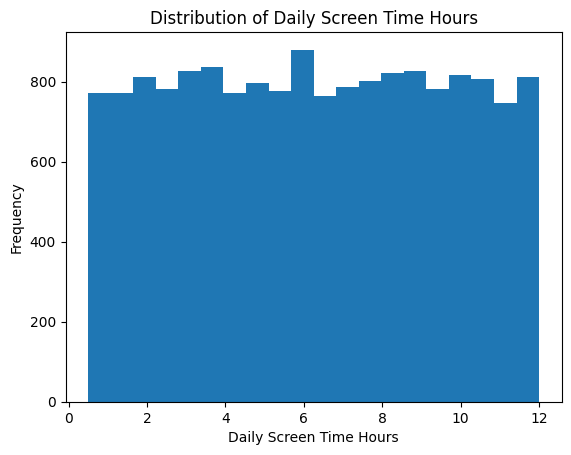

In [20]:
plt.hist(y_train, bins=20)
plt.xlabel("Daily Screen Time Hours")
plt.ylabel("Frequency")
plt.title("Distribution of Daily Screen Time Hours")
plt.show()

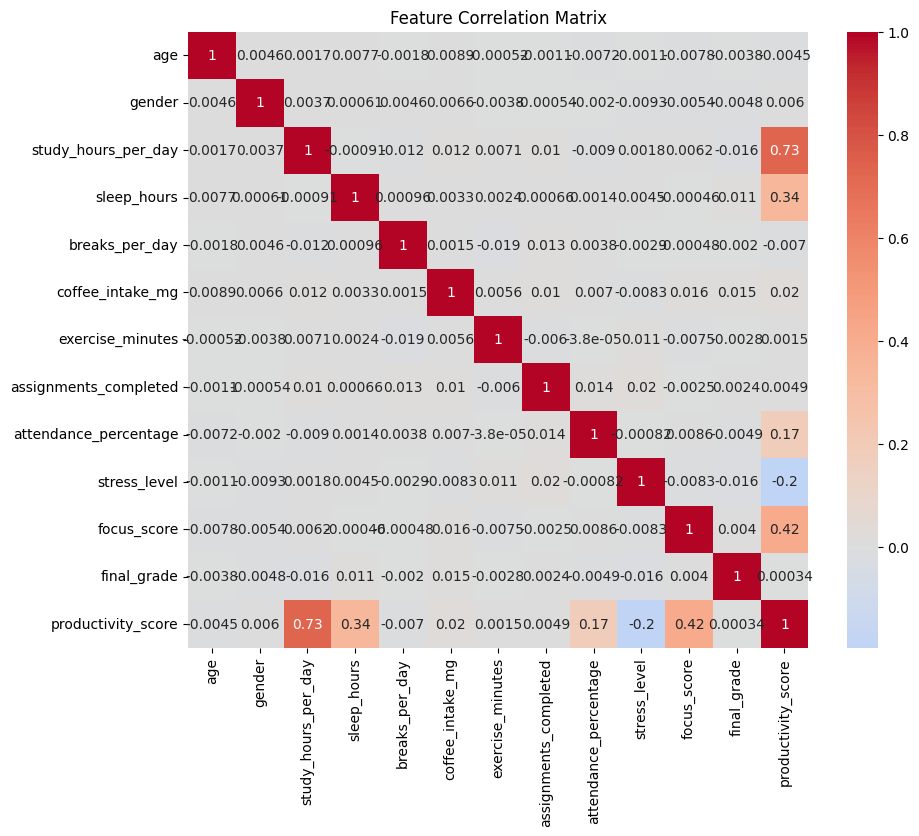

In [21]:
# Feature Correlation Matrix on X_train (to see if the decision tree might have multiple options for the same thing)
# If there were highly correlated features, we could drop one of them for simplicity
# According to the correlation matrix below, there don't seem to be any features that are that highly correlated
# Edit: there does seem to be one strong correlation (study_hours_per_day and productivity_score), so I will remove productivity_score
# Edit #2: After removing productivity_score there was a significant drop in performance, so I added it back in

# Compute correlation matrix
corr_matrix = X_train_encoded.corr()

# Plot correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title("Feature Correlation Matrix")
plt.show()

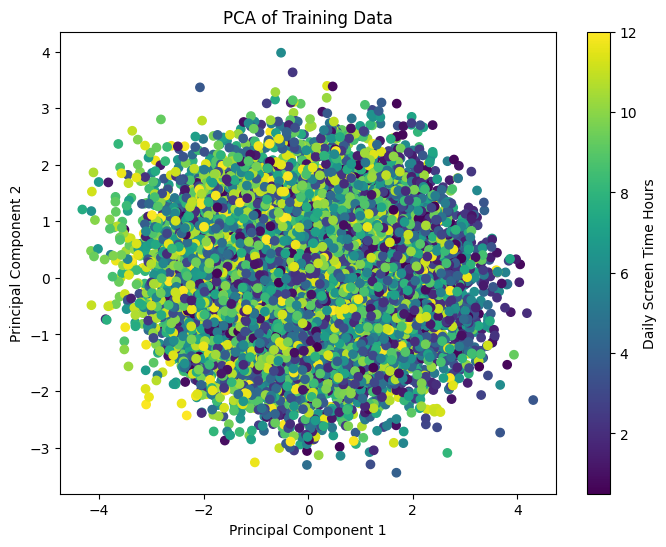

In [22]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
plt.figure(figsize=(8, 6))
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA of Training Data")
plt.colorbar(label="Daily Screen Time Hours")
plt.show()

# Analysis: This PCA plot does not give me confidence in decision tree/single layer neural network models.
# The data does not seem to follow a roughly linear boundary, so a multilayer neural network might be the best option

In [31]:
# Decision Tree Classifier
model = DecisionTreeRegressor()
model.fit(X_train_encoded, y_train)

y_pred = model.predict(X_test_encoded)
train_mse = mean_squared_error(y_train, model.predict(X_train_encoded))
mse = mean_squared_error(y_test, y_pred)

print("Generalization Error:", mse - train_mse)
print(f"Mean Squared Error: {mse}")
print("Depth:", model.get_depth())
print("Number of Leaves:", model.get_n_leaves())

# Plot a visual of the decision tree
plt.figure(figsize=(20, 10))
plot_tree(model, filled=True, feature_names=X_train_encoded.columns)
plt.show()

Generalization Error: 6.63057685
Mean Squared Error: 6.63057685
Depth: 29
Number of Leaves: 15881


KeyboardInterrupt: 

Mean Squared Error (Regularized): 9.480267810015851
Depth (Regularized): 3


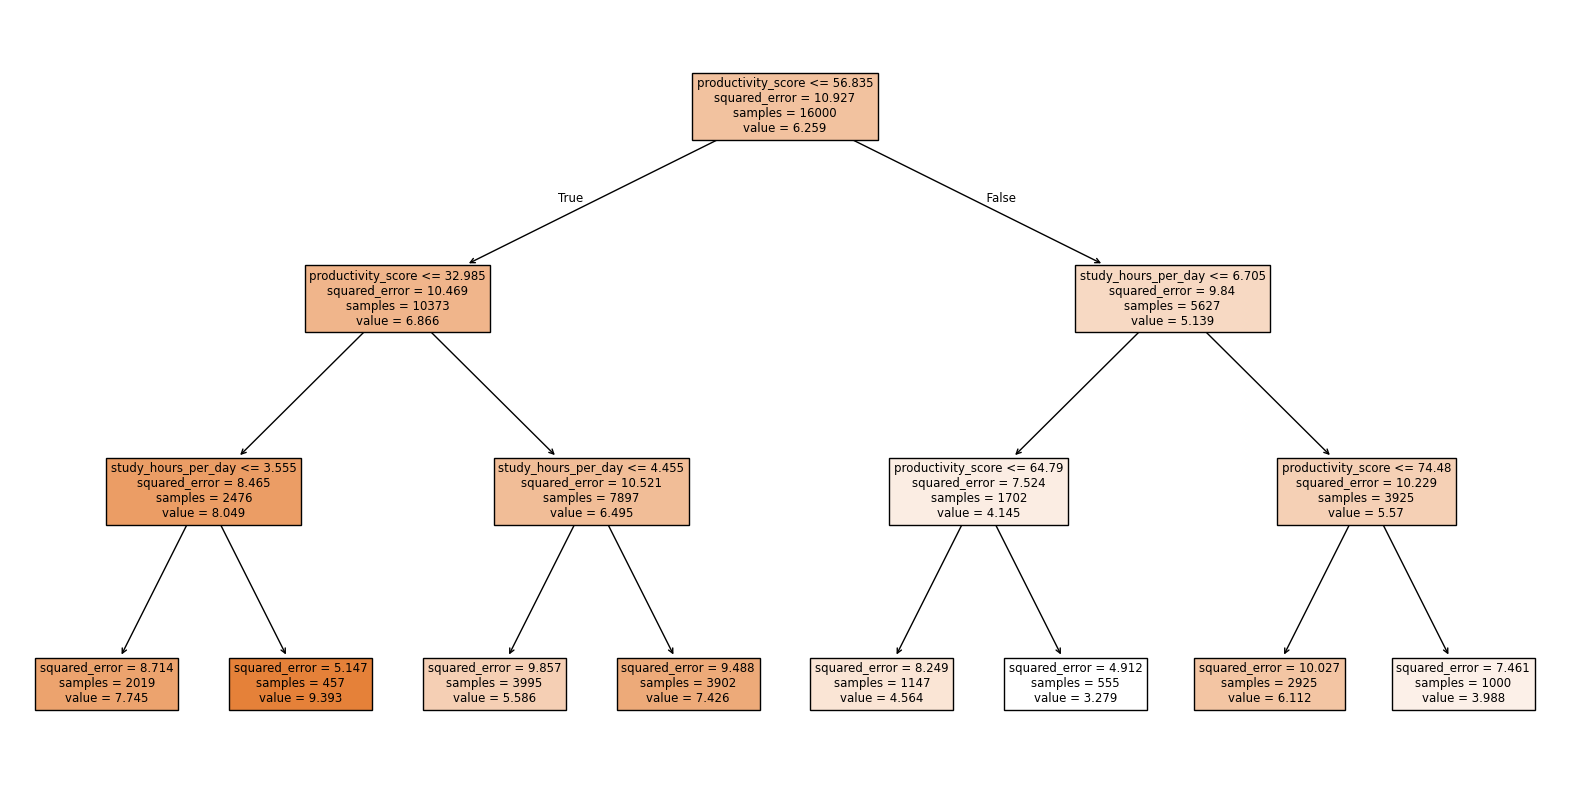

In [24]:
# Regularized Decision Tree Classifier
model_reg = DecisionTreeRegressor(max_depth=3)
model_reg.fit(X_train_encoded, y_train)
y_pred_reg = model_reg.predict(X_test_encoded)
mse_reg = mean_squared_error(y_test, y_pred_reg)

print(f"Mean Squared Error (Regularized): {mse_reg}")
print("Depth (Regularized):", model_reg.get_depth())

# Plot a visual of the regularized decision tree
plt.figure(figsize=(20, 10))
plot_tree(model_reg, filled=True, feature_names=X_train_encoded.columns)
plt.show()

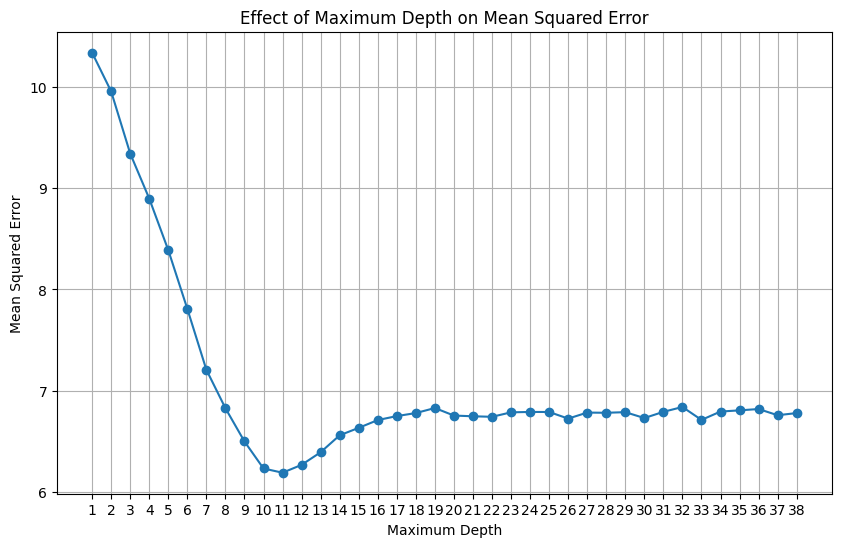

Minimum MSE: 6.189847908806329 at Depth: 11
Generalization Error at Optimal Depth: 3.8243638990096755
Number of Leaves at Optimal Depth: 1681.2


In [36]:
# Since it seems like regularization does help, we make a plot of maximum depth vs mean squared error

depths = range(1, 39) # 39 is the depth of the unregularized decision tree from earlier
mse_values = []
generalization_errors = []
n_leaves_values = []
for depth in depths:
    # Obtain MSEs via a K-fold cross validation approach
    # Also get average generalization error and number of leaves for each depth
    # scores = cross_val_score(DecisionTreeRegressor(max_depth=depth), X_encoded, y, cv=5, scoring='neg_mean_squared_error')
    # mse_values.append(-scores.mean())

    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    temp_mses = []
    temp_generalization_errors = []
    temp_n_leaves = []
    for train_index, test_index in kf.split(X_encoded):
        X_train_fold, X_test_fold = X_encoded.iloc[train_index], X_encoded.iloc[test_index]
        y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]
        
        model_fold = DecisionTreeRegressor(max_depth=depth)
        model_fold.fit(X_train_fold, y_train_fold)
        
        train_mse_fold = mean_squared_error(y_train_fold, model_fold.predict(X_train_fold))
        test_mse_fold = mean_squared_error(y_test_fold, model_fold.predict(X_test_fold))
        
        temp_generalization_errors.append(test_mse_fold - train_mse_fold)
        temp_n_leaves.append(model_fold.get_n_leaves())
        temp_mses.append(test_mse_fold)

    mse_values.append(np.mean(temp_mses))
    generalization_errors.append(np.mean(temp_generalization_errors))
    n_leaves_values.append(np.mean(temp_n_leaves))

plt.figure(figsize=(10, 6))
plt.plot(depths, mse_values, marker='o')
plt.xlabel("Maximum Depth")
plt.ylabel("Mean Squared Error")
plt.title("Effect of Maximum Depth on Mean Squared Error")
plt.xticks(depths)
plt.grid()
plt.show()

# Print Minimum MSE and corresponding depth
min_mse = min(mse_values)
optimal_depth = depths[mse_values.index(min_mse)]
print(f"Minimum MSE: {min_mse} at Depth: {optimal_depth}")
print("Generalization Error at Optimal Depth:", generalization_errors[mse_values.index(min_mse)])
print("Number of Leaves at Optimal Depth:", n_leaves_values[mse_values.index(min_mse)])

Mean Squared Error (Regularized): 6.434996160724191
Depth (Regularized): 11
Generalization Error (Regularized): 3.8369206531387854
Number of Leaves (Regularized): 1544


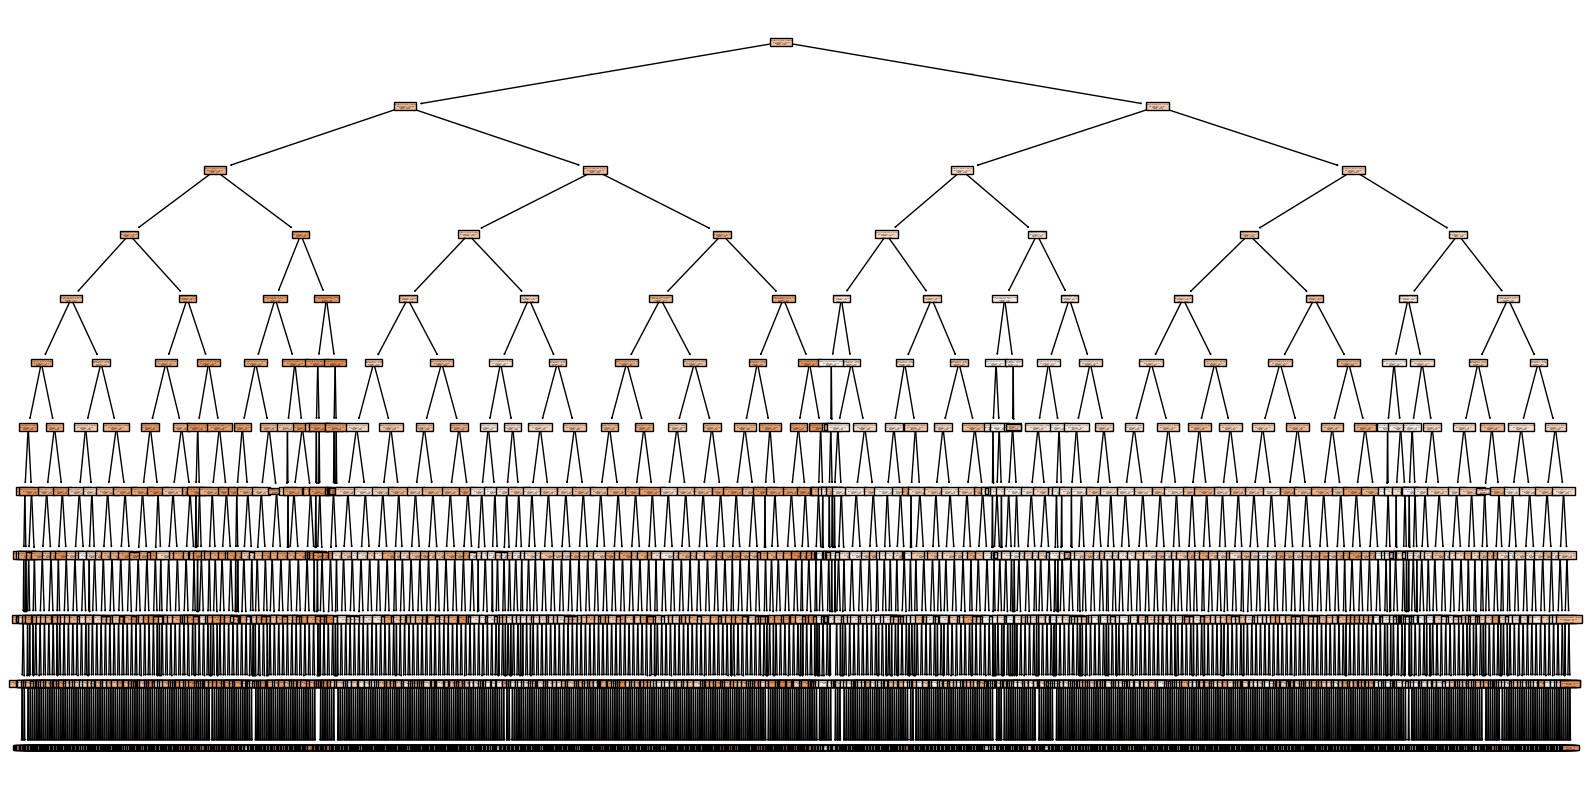

In [50]:
# Regularized Decision Tree Classifier (using best depth from the plot above)
model_reg = DecisionTreeRegressor(max_depth=11)
model_reg.fit(X_train_encoded, y_train)
y_pred_reg = model_reg.predict(X_test_encoded)
mse_reg = mean_squared_error(y_test, y_pred_reg)
train_mse_reg = mean_squared_error(y_train, model_reg.predict(X_train_encoded))

print(f"Mean Squared Error (Regularized): {mse_reg}")
print("Depth (Regularized):", model_reg.get_depth())
print("Generalization Error (Regularized):", mse_reg - train_mse_reg)
print("Number of Leaves (Regularized):", model_reg.get_n_leaves())

# Plot a visual of the regularized decision tree
plt.figure(figsize=(20, 10))
plot_tree(model_reg, filled=True, feature_names=X_train_encoded.columns)
plt.show()

# Analysis: Based on the plot of maximum depth vs. mean squared error, it seems like the best decision tree we can get
# for this dataset is the one below. Simply analyzing the education level of the person

# Analysis: It's also worth nothing that I ran all the decision trees with various train-test splits.
# All splits agreed that the best decision tree had maximum depth 1, but they did not agree on the feature to compare
# Some used Physical_Activity_Hours, some used Income_USD, and some used Education_Level.
# This suggests that there are many equally weak predictors of screen time

In [29]:
# Since the features in the dataset seem to all be weak predictors of screen time,
# we try a random forest regressor to see if it can combine the weak predictors into a stronger predictor
from sklearn.ensemble import RandomForestRegressor
model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf.fit(X_train_encoded, y_train)
y_pred_rf = model_rf.predict(X_test_encoded)
mse_rf = mean_squared_error(y_test, y_pred_rf)
print(f"Mean Squared Error (Random Forest): {mse_rf}")

Mean Squared Error (Random Forest): 2.57186346979


In [68]:
# Evaluate random forest with cross validation
# rf_scores = cross_val_score(model_rf, X_encoded, y, cv=5, scoring='neg_mean_squared_error')
# print(f"Cross-Validated Mean Squared Error (Random Forest): {-rf_scores.mean()}")

mses_rf = []
generalization_errors_rf = []
n_leaves = [] # Sum of number of leaves across all trees in the random forest
average_depths = []

kf = KFold(n_splits=5, shuffle=True, random_state=42)
for train_index, test_index in kf.split(X_encoded):
    X_train_fold, X_test_fold = X_encoded.iloc[train_index], X_encoded.iloc[test_index]
    y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]
    
    model_rf_fold = RandomForestRegressor(n_estimators=100, random_state=42)
    model_rf_fold.fit(X_train_fold, y_train_fold)
    
    train_mse_rf_fold = mean_squared_error(y_train_fold, model_rf_fold.predict(X_train_fold))
    test_mse_rf_fold = mean_squared_error(y_test_fold, model_rf_fold.predict(X_test_fold))
    
    generalization_errors_rf.append(test_mse_rf_fold - train_mse_rf_fold)
    n_leaves.append(sum(estimator.get_n_leaves() for estimator in model_rf_fold.estimators_))
    average_depths.append(np.mean([estimator.get_depth() for estimator in model_rf_fold.estimators_]))
    mses_rf.append(test_mse_rf_fold)

print(f"Cross-Validated Mean Squared Error (Random Forest): {np.mean(mses_rf)}")
print(f"Average Generalization Error (Random Forest): {np.mean(generalization_errors_rf)}")
print(f"Average Number of Leaves (Random Forest): {np.mean(n_leaves)}")
print(f"Average Depth (Random Forest): {np.mean(average_depths)}")

Cross-Validated Mean Squared Error (Random Forest): 3.1283058196724998
Average Generalization Error (Random Forest): 2.6877930097835
Average Number of Leaves (Random Forest): 1005130.4
Average Depth (Random Forest): 26.191999999999997


In [14]:
import numpy as np
from sklearn.metrics import mean_squared_error

y_pred_mean = np.full_like(y_test, y_train.mean())
mse_baseline = mean_squared_error(y_test, y_pred_mean)
print("Baseline MSE:", mse_baseline)

Baseline MSE: 11.170790548931251
